# Milestone 2

## I. Introduction

========================================================================================================

Milestone 2

Name  : Bagus Rifky Riyanto

Batch : HCK-27


This program is used to analyze topic "Customers Loan Request Prediction for NIOOS Bank"


========================================================================================================

### A. Background

There are many customers' types and their behaviour when using their money. Many use their credit card as a shortcut to purchase anything they want, and then they pay it later. We can benefit those behaviour to sell our products. The caveat is that there are many customer who always make their payment way passed the promised due date. This isn't good for the growth of the business when our bank has a customers' with that kind of behaviour. To optimize our decision when approving loan application, we use machine learning and data to improve our percentage of low risk customers'. Increasing percentage of low risk customers' can drives our bank profit even higher.

### B. Dataset Description

This dataset is filled with information of NIOOS Bank customers' loan application. Here's the list of columns in this dataset:

- person_age 
- person_gender
- person_education 
- person_income 
- person_emp_exp
- person_home_ownership
- loan_amnt
- loan_intent
- loan_int_rate 
- loan_percent_income 
- cb_person_cred_hist_length 
- credit_score 
- previous_loan_defaults_on_file 
- loan_status

- Link to dataset: https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data
- Link to deployment: https://huggingface.co/spaces/bagusrifky7/P1M2_bagus_rifky

### C. Problem Statements

Getting low-risk customers' has always be an objective of every business. To easier and faster prediction for customers' loan request, we will use machine learning model. We can compare 5 machine learning models that we will use on this analysis. The model that we will use are K-Nearest Neighbors, Decision Tree, Support Vector Machine, Random Forest, and Boosting. It is important for our's company to decrease the potential number of customers' that will make payments passed the due date.

### D. Objective

Objectives for this analysis is:

- Predicting customers' loan application approval for NIOOS Bank.
- Helping credit risk approval team on loan approval decision.
- Helping marketing team when doing promotion of our financial products.

## II. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from scipy import stats
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from imblearn.over_sampling import SMOTENC
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, classification_report, ConfusionMatrixDisplay, confusion_matrix, roc_curve, roc_auc_score
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score


Libraries explanations:

- Pandas and Numpy are use to create and manipulating table.
- Sklearn is uses to import model, pipeline, and metric for evaluation.
- Pickle is uses to export model for inference process.
- Seaborn and Mathplotlib are use for visualisation.
- Scipy is uses for importing statistic for calculation.
- IMB Learn is uses for import method for balancing the data.

## III. Data Loading

### A. Load Data

In [2]:
# import the data
data = pd.read_csv('loan_data.csv')
df = data.copy()
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [3]:
# displaying the first 10 data
df.head(10)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
5,21.0,female,High School,12951.0,0,OWN,2500.0,VENTURE,7.14,0.19,2.0,532,No,1
6,26.0,female,Bachelor,93471.0,1,RENT,35000.0,EDUCATION,12.42,0.37,3.0,701,No,1
7,24.0,female,High School,95550.0,5,RENT,35000.0,MEDICAL,11.11,0.37,4.0,585,No,1
8,24.0,female,Associate,100684.0,3,RENT,35000.0,PERSONAL,8.90,0.35,2.0,544,No,1
9,21.0,female,High School,12739.0,0,OWN,1600.0,VENTURE,14.74,0.13,3.0,640,No,1


In [4]:
# displayinng the last 10 data
df.tail(10)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
44990,31.0,male,Master,136832.0,9,RENT,12319.0,PERSONAL,16.92,0.09,7.0,722,No,1
44991,24.0,male,High School,37786.0,0,MORTGAGE,13500.0,EDUCATION,13.43,0.36,4.0,612,No,1
44992,23.0,female,Bachelor,40925.0,0,RENT,9000.0,PERSONAL,11.01,0.22,4.0,487,No,1
44993,27.0,female,High School,35512.0,4,RENT,5000.0,PERSONAL,15.83,0.14,5.0,505,No,1
44994,24.0,female,Associate,31924.0,2,RENT,12229.0,MEDICAL,10.70,0.38,4.0,678,No,1
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1
44999,24.0,male,High School,51609.0,1,RENT,6665.0,DEBTCONSOLIDATION,17.05,0.13,3.0,628,No,1


### B. Data Overview

In [5]:
# displaying dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

Explanations:

- Every columns in this dataset have 45000 non-null values from 45000 rows.
- person_age, person_income, loan_amnt, loan_int_rate, loan_percent_incomme, and cb_person_cred_hist_length column is a float data type.
- person_gender, person_education, person_home_owenership, loan_intent, and previous_loan_defaults_on_file column is an object data type.
- person_emp_exp and credit_score column is an interger data type.
- There's no missing value in the dataset.

In [6]:
# list of unique values

# showing maximum rows
pd.set_option('display.max_colwidth', None)

# create variable to convert table to list
df_to_list = df.to_dict('list')

# empty list for unique value table
list_unique = []

# looping for unique values table
for col, val in df_to_list.items():
    val = set(val)
    val = list(val)
    list_unique.append([col, val])

# displaying dataframe 
unique = pd.DataFrame(columns = ['col_name', 'col_unique_val'], data = list_unique)
unique


,col_name,col_unique_val
0,person_age,"[144.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 64.0, 65.0, 66.0, 67.0, 69.0, 70.0, 73.0, 76.0, 78.0, 80.0, 84.0, 94.0, 109.0, 116.0, 123.0]"
1,person_gender,"[female, male]"
2,person_education,"[Bachelor, Master, High School, Doctorate, Associate]"
3,person_income,"[131096.0, 131166.0, 131204.0, 262288.0, 131226.0, 131293.0, 131306.0, 131309.0, 262431.0, 131359.0, 262437.0, 131383.0, 131430.0, 131462.0, 131466.0, 131470.0, 262563.0, 262569.0, 131497.0, 131524.0, 131545.0, 262666.0, 131635.0, 131650.0, 131653.0, 131655.0, 131687.0, 131708.0, 131726.0, 131731.0, 131737.0, 131747.0, 131772.0, 131773.0, 131792.0, 131817.0, 131819.0, 131826.0, 131843.0, 131856.0, 131867.0, 131871.0, 131883.0, 131884.0, 131897.0, 131910.0, 131915.0, 132043.0, 132059.0, 132073.0, 132094.0, 132178.0, 132198.0, 132224.0, 132284.0, 132310.0, 132315.0, 132324.0, 132353.0, 132366.0, 132412.0, 132422.0, 132495.0, 132566.0, 132569.0, 132575.0, 132585.0, 132597.0, 132600.0, 132605.0, 132618.0, 132621.0, 132624.0, 132625.0, 132630.0, 132641.0, 132669.0, 132675.0, 132677.0, 132678.0, 132683.0, 132689.0, 132690.0, 132710.0, 132711.0, 132712.0, 132713.0, 132714.0, 132718.0, 132728.0, 132731.0, 132735.0, 132741.0, 132742.0, 132743.0, 132746.0, 132749.0, 263825.0, 132755.0, 132761.0, ...]"
4,person_emp_exp,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 57, 58, 61, 62, 76, 85, 93, 100, 101, 121, 124, 125]"
5,person_home_ownership,"[MORTGAGE, OWN, RENT, OTHER]"
6,loan_amnt,"[8197.0, 8200.0, 8203.0, 8204.0, 8206.0, 16400.0, 8212.0, 8217.0, 8225.0, 16425.0, 8235.0, 24619.0, 8237.0, 8238.0, 24623.0, 16432.0, 24625.0, 24626.0, 8243.0, 24631.0, 8250.0, 8251.0, 24636.0, 8254.0, 16447.0, 8257.0, 16450.0, 21180.0, 8260.0, 8262.0, 8263.0, 8274.0, 8275.0, 8276.0, 32857.0, 16474.0, 8284.0, 8288.0, 16488.0, 8299.0, 8300.0, 16493.0, 24689.0, 16500.0, 8309.0, 16503.0, 24696.0, 24699.0, 24706.0, 8325.0, 24712.0, 8330.0, 16525.0, 24717.0, 11426.0, 8345.0, 8346.0, 8350.0, 16542.0, 21199.0, 8355.0, 8356.0, 8357.0, 24748.0, 24750.0, 8367.0, 8368.0, 8371.0, 8372.0, 8375.0, 24759.0, 8379.0, 16573.0, 8383.0, 8385.0, 8389.0, 8390.0, 24775.0, 24780.0, 8397.0, 8399.0, 8400.0, 8401.0, 8402.0, 24784.0, 8404.0, 16598.0, 16600.0, 8411.0, 24796.0, 8414.0, 24800.0, 8419.0, 8420.0, 24806.0, 8423.0, 33000.0, 8427.0, 8428.0, 8429.0, ...]"
7,loan_intent,"[HOMEIMPROVEMENT, EDUCATION, VENTURE, PERSONAL, MEDICAL, DEBTCONSOLIDATION]"
8,loan_int_rate,"[5.5, 5.75, 6.0, 6.75, 6.5, 6.25, 11.14, 11.11, 7.75, 14.27, 15.23, 16.02, 17.57, 17.07, 18.39, 20.0, 18.25, 16.77, 17.58, 17.74, 19.41, 19.91, 18.53, 19.47, 7.5, 7.25, 7.0, 8.0, 8.25, 8.5, 8.75, 9.25, 9.0, 9.5, 9.75, 10.25, 10.75, 10.0, 10.5, 11.25, 11.5, 11.0, 11.75, 12.0, 12.25, 12.5, 12.75, 13.75, 13.25, 13.0, 13.5, 14.5, 14.75, 14.25, 14.0, 15.25, 15.0, 15.75, 15.5, 16.0, 16.75, 16.5, 16.25, 17.5, 17.0, 17.25, 5.97, 6.72, 19.5, 19.25, 8.94, 8.69, 8.19, 8.44, 9.69, 9.19, 9.44, 9.94, 10.69, 10.19, 10.94, 10.44, 11.94, 11.69, 11.19, 11.44, 12.94, 12.19, 12.44, 13.69, 13.94, 13.44, 13.19, 14.94, 14.69, 14.19, 14.44, 15.19, 15.44, 15.94, ...]"
9,loan_percent_income,"[0.49, 0.53, 0.44, 0.19, 0.37, 0.35, 0.13, 0.34, 0.3, 0.27, 0.25, 0.5, 0.42, 0.0, 0.58, 0.59, 0.26, 0.51, 0.18, 0.43, 0.05, 0.11, 0.52, 0.36, 0.61, 0.04, 0.28, 0.2, 0.45, 0.16, 0.12, 0.62, 0.29, 0.21, 0.1, 0.22, 0.17, 0.03, 0.09, 0.23, 0.15, 0.46, 0.38, 0.54, 0.63, 0.55, 0.47, 0.02, 0.14, 0.39, 0.31, 0.06, 0.08, 0.48, 0.56, 0.4, 0.57, 0.01, 0.32, 0.07, 0.24, 0.41, 0.66, 0.33]"


Explanations:

- person_age column is filled with information of customers' age.
- person_gender column is filled with information of customers' gender.
- person_education column is filled with information of customers' level of education.
- person_income columnis filled with information of customers' annual income.
- person_emp_exp column is filled with infomation of customers' employments experience.
- person_home_ownership column is filled with information of customers' home ownership status.
- loan_amnt column is filled with information of customers' request amount of loan.
- loan_intent column is filled with information of customers' loan intention.
- loan_int_rate column is filled with information of customers' loan interest rate.
- loan_percent_income column is filled with information of customers' percentage of loan amount from annual income.
- cb_person_cred_hist_length column is filled with information of customers' length of credit history(in years).
- credit_score column is filled with information of customers' credit score.
- previous_loan_defaults_on_file is filled with informations of customers' previous loan defaults
- loan_status is filled with informations of customers' loan approval status.

In [7]:
# check tabel description
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,45000.0,27.764178,6.045108,20.00,24.00,26.00,30.00,144.00
person_income,45000.0,80319.053222,80422.498632,8000.00,47204.00,67048.00,95789.25,7200766.00
person_emp_exp,45000.0,5.410333,6.063532,0.00,1.00,4.00,8.00,125.00
loan_amnt,45000.0,9583.157556,6314.886691,500.00,5000.00,8000.00,12237.25,35000.00
loan_int_rate,45000.0,11.006606,2.978808,5.42,8.59,11.01,12.99,20.00
loan_percent_income,45000.0,0.139725,0.087212,0.00,0.07,0.12,0.19,0.66
cb_person_cred_hist_length,45000.0,5.867489,3.879702,2.00,3.00,4.00,8.00,30.00
credit_score,45000.0,632.608756,50.435865,390.00,601.00,640.00,670.00,850.00
loan_status,45000.0,0.222222,0.415744,0.00,0.00,0.00,0.00,1.00


### C. Change Columns Name

In [8]:
# change columns name
df = df.rename(columns = {'cb_person_cred_hist_length': 'cred_hist_length',
                'previous_loan_defaults_on_file': 'prev_loan_defaults',
                'loan_amnt': 'loan_amount'})
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amount,loan_intent,loan_int_rate,loan_percent_income,cred_hist_length,credit_score,prev_loan_defaults,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


Explanation:

- cb_person_cred_hist_length column name is change to cred_hist_length.
- previous_loan_defaults_on_file column name is change to prev_loan_defaults.
- loan_amnt column name is change to loan_amount

The purpose of changing the column's name is for easier analysis.

In [169]:
df.to_csv('fix_data.csv', index = False)

## V. Exploratory Data Analysis

### A. Relationship Between Customers' Income, History of Credit Length, and Credit Score to Loan Approval

In [9]:
print(f"person_income skewness: {df['person_income'].skew()}")
print(f"cred_hist_length skewness: {df['cred_hist_length'].skew()}")
print(f"credit_score skewness: {df['credit_score'].skew()}")

person_income skewness: 34.137583132969915
cred_hist_length skewness: 1.6317199538415355
credit_score skewness: -0.6102608322577946


Explanations:

Based on the calculations above, person_income, cred_hist_length, and credit_score column have skewed distributions. We will check the relationship between those three columns to loan approval column with point-biserial correlation test. The reason we use this type of correlation test because we gonna check relationships between continuous variable and binary variable.

In [10]:
list_bsr = ['person_income', 'cred_hist_length', 'credit_score']

for col in list_bsr:
    corr_bsr, pval_bsr = stats.pointbiserialr(df['loan_status'], df[col])
    print(f"Correlation value between {col} and loan_status column: {corr_bsr}")
    print(f"P-value: {pval_bsr}")

Correlation value between person_income and loan_status column: -0.1358077168357424
P-value: 3.483099416950792e-184
Correlation value between cred_hist_length and loan_status column: -0.01485068366098595
P-value: 0.0016305156277469784
Correlation value between credit_score and loan_status column: -0.007647176334884978
P-value: 0.10476273051043242


Explanations:

Based on the calculations above, person_income and cred_hist_length column have a significant correlation to loan_status column. Meanwhile, credit_score and loan_status don't have a significant correlation between them. Those analyses are determined by the p-value. If we take a look at correlation value, there's a weak correlation between person_income and cred_hist_length column to loan_status column.

We can conclude that customers' loan approval are influenced by customers' income and their history of credit length. Meanwhile, customers' loan approval are not influenced by customers' credit score.

### B. What Age Categories Have The Most Loan Applications?

In [11]:
# create copy of the table
df_age = df.copy()
df_age

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amount,loan_intent,loan_int_rate,loan_percent_income,cred_hist_length,credit_score,prev_loan_defaults,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


[For age category, we will use category based on MeSH age-range.](https://www.researchgate.net/figure/Age-range-classes-defined-by-the-Age-Ontology-Age-range-classes-were-generally-defined_fig1_271840217)

In [12]:
# create empty list for age category
list_age = []

# looping for categorize age
for age in df['person_age']:
    if 24 >= age >= 19.00: # 19 to 24 categorize as young adult
        list_age.append('Young Adult')
    elif 45 > age > 24: # 25 to 44 categorize as adult
        list_age.append('Adult')
    elif 64 > age >= 45: # 45 to 63 categorize as middle aged
        list_age.append('Middle Aged')
    else: # 64 and above categorize as aged
        list_age.append('Aged')

# adding category to the table
df_age['age_category'] = list_age
df_age

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amount,loan_intent,loan_int_rate,loan_percent_income,cred_hist_length,credit_score,prev_loan_defaults,loan_status,age_category
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1,Young Adult
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0,Young Adult
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1,Adult
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1,Young Adult
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1,Young Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1,Adult
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1,Adult
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1,Adult
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1,Adult


In [13]:
# table for visuaiize the most loan application
# based on age category
df_age_app = df_age.groupby(['age_category'])['loan_status'].count().reset_index()
df_age_app = df_age_app.rename(columns = {'loan_status': 'customer_total'})
df_age_app

,age_category,customer_total
0,Adult,28169
1,Aged,56
2,Middle Aged,841
3,Young Adult,15934


Text(0, 0.5, 'Customer Total')

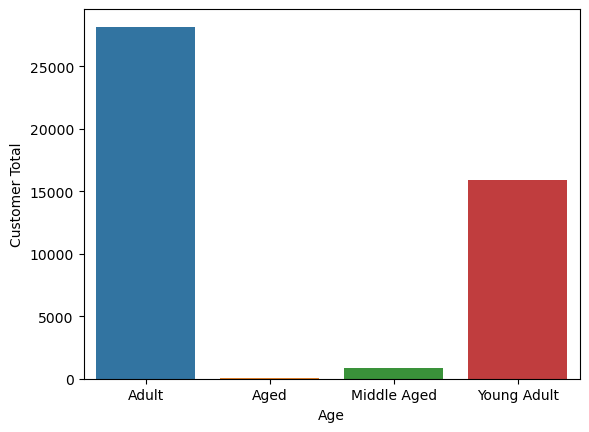

In [14]:
# plotting bar chart for the most loan application
sns.barplot(df_age_app, x = 'age_category', y = 'customer_total')
plt.xlabel('Age')
plt.ylabel('Customer Total')

c:\Users\Asus\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0, 0.5, 'Customer Total')

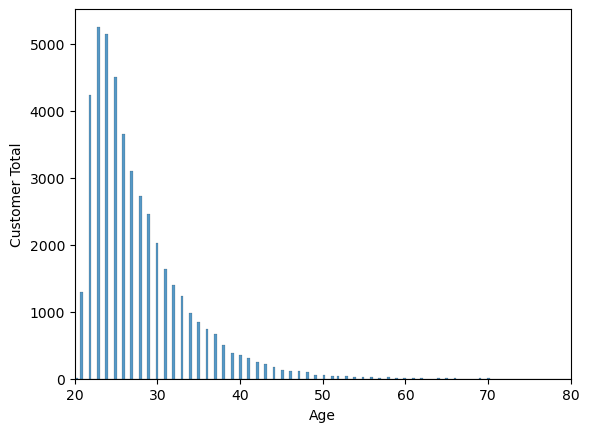

In [15]:
sns.histplot(df_age, x = 'person_age')
plt.xlim(20, 80)
plt.xlabel('Age')
plt.ylabel('Customer Total')

Explanation:

Based on the bar chart above, customers' in the adult category have the most loan applications to our bank, meanwhile customers' in the aged category have the lowest loan applications to our bank. If we take a look on the histogram above, customers' age from range 20 to 30 years old have the most loan applications to our bank. We can conclude that there's a lot of customers that interested to our financial products from range of 20 to 30 years old. 

### C. How's The Income Distribution of Our Approved Customers' Loan?

In [16]:
df_income = df[df['loan_status'] == 1]

c:\Users\Asus\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


(0.0, 300000.0)

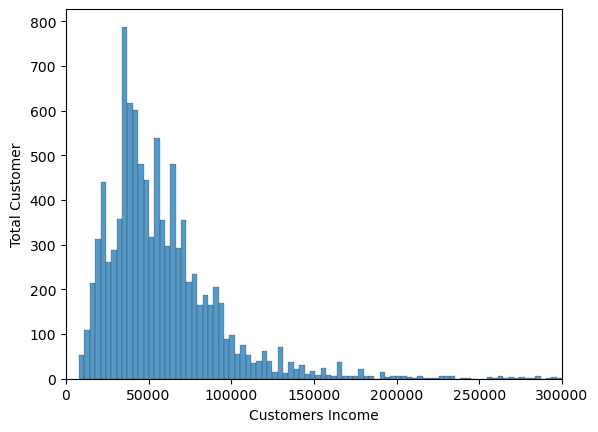

In [17]:
# plotting histogram for income distribution
sns.histplot(df_income, x = 'person_income')
plt.xlabel('Customers Income')
plt.ylabel('Total Customer')
plt.xlim(0, 300000)

Explanation:

Based on the income distribution above, most of our approved customers' loan income is in a range between 35000 dollar to 70000 dollar. We can conclude that income in a range between 35000 to 70000 can be considered as a factor for loan request approval.

### D. How’s The Approved Customer Loan Credit Score Distribution?


In [18]:
# filtering the table
df_lc_app = df[df['loan_status'] == 1]
df_lc_app

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amount,loan_intent,loan_int_rate,loan_percent_income,cred_hist_length,credit_score,prev_loan_defaults,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
5,21.0,female,High School,12951.0,0,OWN,2500.0,VENTURE,7.14,0.19,2.0,532,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


c:\Users\Asus\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0, 0.5, 'Total Customers')

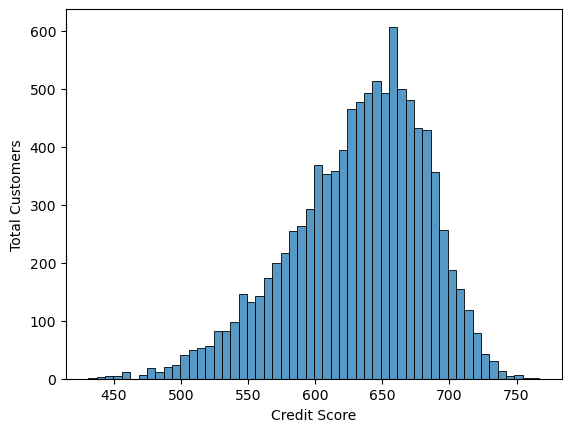

In [19]:
# plotting the distribution
sns.histplot(df_lc_app, x = 'credit_score')
plt.xlabel('Credit Score')
plt.ylabel('Total Customers')

Explanation:

Based on credit score distribution for only approved loan customers', the majority of our customers' credit scores are in the range between 550 to 700. [If we take a look at CIBIL score ranges, 550 to 650 is categorised as average scores and 651 to 750 is categorised as good scores. CIBIL score is used as an interpretation of customers' credit score; the higher the score, the better the quality of our customers. We can conclude that we need to keep improving the quality of our customers'.](https://www.iifl.com/blogs/cibil-score/compare-cibil-score-ranges)

### E. Relationship Between Customers’ Employment Experience and How Much Loan Has Been Requested

In [20]:
# calculating skewness value
print(f"person_emp_exp skewness: {df['person_emp_exp'].skew()}")
print(f"loan_amount skewness: {df['loan_amount'].skew()}")

person_emp_exp skewness: 2.5949173726318255
loan_amount skewness: 1.1797312856279223


In [21]:
# check correlation with spearman test
corr, p_val = stats.spearmanr(df['person_emp_exp'], df['loan_amount'])
print(f"Correlation value: {corr}")
print(f"P-value: {p_val}")

Correlation value: 0.05203352678794256
P-value: 2.313722491761106e-28


Explanation:

We use spearman correlation test because both column have skewed distribution. Based on calculations, there's a weak correlation between those two columns, so we can conclude that there's no significant influenced on requested loan amount based on the higher or lower of customers' employment experience.

### F. Relationship Between Customers’ Loan Intention and Loan Amount Requested

In [22]:
# check correlation with kendall test
corr, p_val = stats.kendalltau(df['loan_intent'], df['loan_amount'])
print(f"Correlation value: {corr}")
print(f"P-value: {p_val}")

Correlation value: 0.0018310322792054869
P-value: 0.5951533877909934


Explanation:

We use the Kendall correlation test because we gonna calculating the correlation value between categorical and numerical columns. Based on the calculation, the P-value shows us that there's no correlation between the two columns, and the correlation value shows us that there's no significant customers' loan intention influenced on the requested loan amount. We can conclude that any customers' loan intention doesn't make the customers' make a specific amount of the requested loan.

### G. How's The Distribution of Customers' Credit Scores When The Loan Intention Is For Debt Consolidation?

In [23]:
# filtering the table for debt consolidation intention only
df_debt = df[df['loan_intent'] == 'DEBTCONSOLIDATION']
df_debt

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amount,loan_intent,loan_int_rate,loan_percent_income,cred_hist_length,credit_score,prev_loan_defaults,loan_status
15,23.0,female,Master,600891.0,5,MORTGAGE,30000.0,DEBTCONSOLIDATION,10.65,0.05,3.0,670,Yes,0
18,23.0,male,Bachelor,136628.0,0,RENT,35000.0,DEBTCONSOLIDATION,18.25,0.26,4.0,709,No,1
33,25.0,female,High School,368115.0,3,RENT,24250.0,DEBTCONSOLIDATION,13.85,0.07,3.0,567,Yes,0
37,24.0,male,High School,78026.0,3,RENT,30000.0,DEBTCONSOLIDATION,14.54,0.38,3.0,582,No,1
39,23.0,female,High School,86811.0,0,RENT,30000.0,DEBTCONSOLIDATION,11.01,0.35,4.0,602,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44983,30.0,male,Bachelor,59688.0,8,RENT,16000.0,DEBTCONSOLIDATION,13.87,0.27,7.0,626,No,1
44986,34.0,male,Bachelor,41876.0,14,RENT,19594.0,DEBTCONSOLIDATION,12.03,0.47,8.0,707,No,1
44987,34.0,male,Master,69210.0,9,RENT,2616.0,DEBTCONSOLIDATION,6.33,0.04,7.0,662,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1


c:\Users\Asus\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0, 0.5, 'Total Customers')

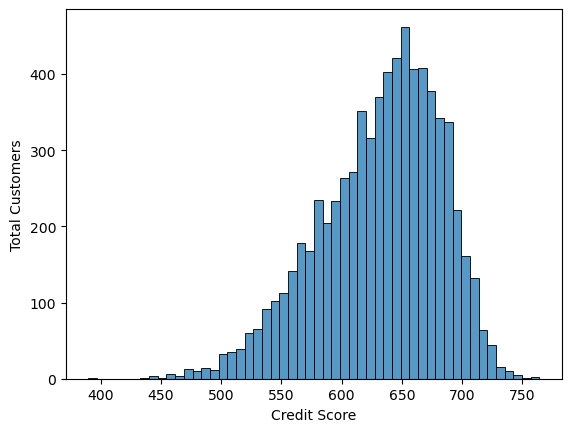

In [24]:
# plotting credit score distribution
sns.histplot(df_debt, x = 'credit_score')
plt.xlabel('Credit Score')
plt.ylabel('Total Customers')

Explanation:

Based on the visualisation above, customers' who requested a loan for debt consolidation mostly have a high score range, between 600 and 700. We can conclude that we can consider an approval of loan to this type of customers. The caveat is we need to pay attention to the loan maturity with this type of customers' since we doesn't have the data of how this type of customers' uses their money.

### H. What's The Percentage of Male and Female With Approved Loan?

([<matplotlib.patches.Wedge at 0x1cc60a00d10>,
 [Text(-0.15654637770487634, 1.0888035780743386, 'Male'),
  Text(0.15654647964602333, -1.0888035634174043, 'Female')],
 [Text(-0.0853889332935689, 0.593892860767821, '54.5%'),
  Text(0.08538898889783089, -0.5938928527731295, '45.5%')])

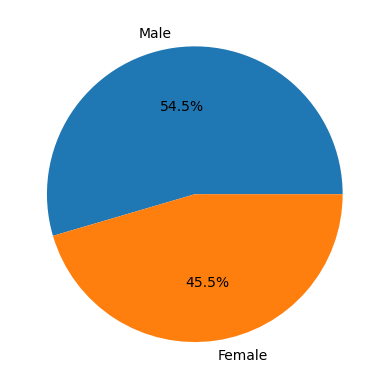

In [6]:
# create a df for male and female
df_male = df[df['person_gender'] == 'male']
df_female = df[df['person_gender'] == 'female']
df_male = df_male[df_male['loan_status'] == 1]
df_female = df_female[df_female['loan_status'] == 1]

# percentage of every gender table to main table
male_p = (len(df_male)/len(df)) * 100
female_p = (len(df_female))/len(df) * 100

# create labels and sizes parameter
labels = 'Male', 'Female'
sizes = [round(male_p), round(female_p)]

# plotting pie chart
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%')

Explanation:

Based on the pie chart above, our customers' with approved loan are 55% male and 45% female. We have quite balanced customers' spreads, because the difference between male and female customer is under 10%.

## VI. Feature Engineering

### A. Handle Cardinality

In [26]:
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amount,loan_intent,loan_int_rate,loan_percent_income,cred_hist_length,credit_score,prev_loan_defaults,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [27]:
# list of unique values

# showing maximum rows
pd.set_option('display.max_colwidth', None)

# empty list for unique value table
cat_cols = ['person_gender', 'person_education', 'person_home_ownership',
            'loan_intent', 'prev_loan_defaults']
list_cardinal = []

# looping for unique values table
for col in cat_cols:
    list_cardinal.append([col, df[col].nunique(), df[col].unique()])
# displaying dataframe 
unique = pd.DataFrame(columns = ['col_name', 'total_unique_val', 'col_unique_val'], data = list_cardinal)
unique


,col_name,total_unique_val,col_unique_val
0,person_gender,2,"[female, male]"
1,person_education,5,"[Master, High School, Bachelor, Associate, Doctorate]"
2,person_home_ownership,4,"[RENT, OWN, MORTGAGE, OTHER]"
3,loan_intent,6,"[PERSONAL, EDUCATION, MEDICAL, VENTURE, HOMEIMPROVEMENT, DEBTCONSOLIDATION]"
4,prev_loan_defaults,2,"[No, Yes]"


Explanation:

Based on the table above, we don't need to handle cardinality because the total unique value per column isn't large.

### B. Split Betweeen X(Features) and y(Target)

In [28]:
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amount,loan_intent,loan_int_rate,loan_percent_income,cred_hist_length,credit_score,prev_loan_defaults,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [29]:
X = df.drop(columns = ['loan_status'])
y = df['loan_status']

In [30]:
# displaying features
X

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amount,loan_intent,loan_int_rate,loan_percent_income,cred_hist_length,credit_score,prev_loan_defaults
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No


In [31]:
# displaying target 
y

0        1
1        0
2        1
3        1
4        1
        ..
44995    1
44996    1
44997    1
44998    1
44999    1
Name: loan_status, Length: 45000, dtype: int64

### C. Split Between Train and Test Set

In [32]:
# splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y,  test_size = 0.3, random_state = 45)

# train set
X_train

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amount,loan_intent,loan_int_rate,loan_percent_income,cred_hist_length,credit_score,prev_loan_defaults
1315,26.0,female,High School,89843.0,0,RENT,16000.0,HOMEIMPROVEMENT,14.84,0.18,3.0,618,Yes
15610,23.0,male,Master,180839.0,3,MORTGAGE,30000.0,MEDICAL,9.99,0.17,3.0,689,Yes
16431,24.0,male,Bachelor,42001.0,0,RENT,7000.0,VENTURE,13.16,0.17,4.0,568,No
19201,27.0,male,High School,142952.0,9,RENT,13425.0,PERSONAL,15.99,0.09,10.0,549,No
12626,25.0,male,Bachelor,101814.0,5,MORTGAGE,5000.0,VENTURE,10.99,0.05,2.0,705,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32469,51.0,male,High School,88355.0,30,MORTGAGE,5700.0,PERSONAL,7.66,0.06,28.0,691,Yes
16317,25.0,male,High School,87486.0,1,RENT,17000.0,DEBTCONSOLIDATION,7.88,0.19,3.0,548,No
12895,21.0,male,Associate,45041.0,0,OWN,18000.0,VENTURE,10.25,0.40,4.0,649,Yes
6012,23.0,female,High School,58448.0,2,MORTGAGE,10000.0,PERSONAL,10.65,0.17,3.0,654,No


In [33]:
# test set
X_test

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amount,loan_intent,loan_int_rate,loan_percent_income,cred_hist_length,credit_score,prev_loan_defaults
37345,43.0,male,Associate,151037.0,19,MORTGAGE,8825.0,EDUCATION,7.88,0.06,13.0,639,Yes
15429,23.0,female,High School,162907.0,1,OWN,16000.0,VENTURE,6.91,0.10,3.0,666,Yes
2849,22.0,male,Bachelor,72890.0,1,RENT,3000.0,PERSONAL,11.89,0.04,4.0,657,Yes
3906,26.0,male,Bachelor,49265.0,4,RENT,4000.0,EDUCATION,6.76,0.08,4.0,603,Yes
24544,34.0,female,Master,90086.0,14,OWN,7200.0,VENTURE,6.62,0.08,7.0,671,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12991,25.0,female,Master,103015.0,1,RENT,12000.0,DEBTCONSOLIDATION,12.42,0.12,4.0,709,No
1083,24.0,female,High School,85015.0,2,RENT,17600.0,HOMEIMPROVEMENT,10.62,0.21,2.0,671,No
9502,26.0,male,Master,116847.0,3,RENT,8000.0,DEBTCONSOLIDATION,13.61,0.07,3.0,704,Yes
7659,26.0,male,High School,65673.0,4,MORTGAGE,10000.0,HOMEIMPROVEMENT,7.51,0.15,3.0,610,Yes


In [34]:
y_train.value_counts()

loan_status
0    24627
1     6873
Name: count, dtype: int64

Explanation:

Based on the information above, value 1 is the minority in the data. The percentange of minority in the data is 21%, and it is classified as mild imbalance. We need to do a data balancing for this data.

### D. Data Balancing

In [35]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31500 entries, 1315 to 6558
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   person_age             31500 non-null  float64
 1   person_gender          31500 non-null  object 
 2   person_education       31500 non-null  object 
 3   person_income          31500 non-null  float64
 4   person_emp_exp         31500 non-null  int64  
 5   person_home_ownership  31500 non-null  object 
 6   loan_amount            31500 non-null  float64
 7   loan_intent            31500 non-null  object 
 8   loan_int_rate          31500 non-null  float64
 9   loan_percent_income    31500 non-null  float64
 10  cred_hist_length       31500 non-null  float64
 11  credit_score           31500 non-null  int64  
 12  prev_loan_defaults     31500 non-null  object 
dtypes: float64(6), int64(2), object(5)
memory usage: 3.4+ MB


In [36]:
# balancing the data
smotenc = SMOTENC([1, 2, 5, 7, 12], random_state = 45)
X_train, y_train = smotenc.fit_resample(X_train, y_train)
y_train.value_counts()

loan_status
0    24627
1    24627
Name: count, dtype: int64

Explanation:

Based on the information above, the total of the data of value 0 and 1 is the same.

### E. Handling Outliers

In [37]:
# looping uto determine type of distribution

num_cols = ['person_age', 'person_income', 'person_emp_exp',
            'loan_amount', 'loan_int_rate', 'loan_percent_income',
            'cred_hist_length', 'credit_score']

# empty list for outlier table
list_outlier = []

# looping for determining the outlier
for column in num_cols:
    list_outlier.append([column, round(X_train[column].skew(),1), np.where(0.5 >= X_train[column].skew() >= -0.5,
                                                                      'normal', 'skewed')])

# store it to variable and display it   
skewness = pd.DataFrame(columns = ['col_name', 'skew_value', 'distribution_type'], data = list_outlier)
skewness

,col_name,skew_value,distribution_type
0,person_age,2.4,skewed
1,person_income,27.1,skewed
2,person_emp_exp,2.5,skewed
3,loan_amount,1.1,skewed
4,loan_int_rate,0.0,normal
5,loan_percent_income,0.8,skewed
6,cred_hist_length,1.7,skewed
7,credit_score,-0.6,skewed


Explanation:

Based on the table above, person_age, person_income, person_emp_exp, loan_amount, loan_percent_income, cred_hist_length, and credit_score column has skewed distribution. The only column that have normal distribution is loan_int_rate.

In [38]:
# empty list
columns = []
lower_bound = []
upper_bound = []
percent_total_outlier = []

for row in range (0, len(skewness)):
  column = skewness['col_name'][row]
  # if it's have skewed distribution
  if skewness['distribution_type'][row] == 'skewed':
    IQR = X_train[column].quantile(0.75) - X_train[column].quantile(0.25)
    lower_boundary = X_train[column].quantile(0.25) - (IQR * 3)
    upper_boundary = X_train[column].quantile(0.75) + (IQR * 3)
  # if it's have normal distribution
  else:
    lower_boundary = X_train[column].mean() - 3* X_train[column].std()
    upper_boundary = X_train[column].mean() + 3* X_train[column].std()
  # append to a list
  columns.append(column)
  lower_bound.append(lower_boundary)
  upper_bound.append(upper_boundary)
  totout = ((len(X_train[X_train[column] > upper_boundary]) / len(X_train) * 100) + (len(X_train[X_train[column] < lower_boundary]) / len(X_train) * 100))
  percent_total_outlier.append(totout)

# create a table for upper boundary, lower boundary, and percentage of total outlier
outliers = pd.DataFrame({
    'column': columns,
    'upper_boundary': [round(upper_bound,2) for upper_bound in upper_bound],
    'lower_boundary': [round(lower_bound,2) for lower_bound in lower_bound],
    'percentage_total_outlier': [round(percent_total_outlier,2) for percent_total_outlier in percent_total_outlier]
})
outliers

,column,upper_boundary,lower_boundary,percentage_total_outlier
0,person_age,48.00,6.00,0.84
1,person_income,224672.00,-95380.25,1.54
2,person_emp_exp,25.00,-17.00,0.94
3,loan_amount,41000.00,-22000.00,0.00
4,loan_int_rate,20.66,2.67,0.00
5,loan_percent_income,0.68,-0.37,0.00
6,cred_hist_length,23.00,-12.00,0.33
7,credit_score,859.00,411.00,0.00


Explanation:

Based on the outlier table above, percentange of outlier in the data are under 5%. It is means that outlier have no significance influenced on the data, so we don't need to handle it.

### F. Handle Missing Values

In [39]:
# check missing values on set train
X_train.isnull().sum().sum()

0

In [40]:
# check missing values on set test
X_test.isnull().sum().sum()

0

Explanation:

Based on the information above, there's no missing values in the data.

### G. Feature Selection

In [41]:
# checking feature importances for numerical columns

# list of numerical columns
num_cols = ['person_age', 'person_income', 'person_emp_exp',
            'loan_amount', 'loan_int_rate', 'loan_percent_income',
            'cred_hist_length', 'credit_score']

model_rf = RandomForestClassifier()
model_rf.fit(X_train[num_cols], y_train)

# create dataframe for feature importances
num_selection = pd.DataFrame({
    'col_name': num_cols,
    'feature_importance': model_rf.feature_importances_
})

num_selection

,col_name,feature_importance
0,person_age,0.082528
1,person_income,0.197304
2,person_emp_exp,0.041027
3,loan_amount,0.094396
4,loan_int_rate,0.231922
5,loan_percent_income,0.190071
6,cred_hist_length,0.092304
7,credit_score,0.070449


In [42]:
# checking feature importance for categorical columns

# create empty list for dataframe
list_col = []

# looping for correlation table
for col in cat_cols:
    corr, pval = stats.kendalltau(df[col], df['loan_status'])
    list_col.append([col, corr])

# displaying the table
cat_selection = pd.DataFrame(columns = ['col_name', 'corr_value'], data = list_col)
cat_selection

,col_name,corr_value
0,person_gender,-0.000561
1,person_education,-0.001059
2,person_home_ownership,0.237793
3,loan_intent,-0.066901
4,prev_loan_defaults,-0.543096


Explanation:

We are using Random Forest Classifier for numerical column selection. We can see that person_income, loan_int_rate, and loan_percent_income features are important. Three of those have almost similar values, and their values are better than the other four numerical columns. The other five numerical columns have a really low value, and it is been declared not important when we trained the model.

For selection on categorical columns, we uses kendall correlation test to determine if the feature are correlated or not to the target. The result showed that prev_loan_defaults and person_home_ownership columns is significant when we trained the model. The other three columns have a really low correlation value, and it is so close to zero. If the correlation value is close to zero, then there's no correlation between those column with the target.

## VII. Model Definition

### A. Create Pipeline

In [43]:
# list of numerical and categorical column for pipeline
num_cols = ['person_income', 'loan_int_rate', 'loan_percent_income']
cat_cols = ['person_home_ownership', 'prev_loan_defaults']

In [44]:
# declaration pipeline for scalling and encoding
num_pipeline = Pipeline([('scaler_minmax', MinMaxScaler())])
cat_pipeline = Pipeline([('encode_onehot', OneHotEncoder())])

# pipeline for scalling and encoding process
preprocessing_pipeline = ColumnTransformer([('pipe_num', num_pipeline, num_cols),
                                   ('pipe_cat', cat_pipeline, cat_cols)])

# pipeline for model
knn = KNeighborsClassifier()
svc = SVC(probability = True, random_state = 45)
rfc = RandomForestClassifier(random_state = 45)
dtc = DecisionTreeClassifier(random_state = 45)
boosting = AdaBoostClassifier(random_state=45)

# final pipeline
model_knn = Pipeline([('prepospipe', preprocessing_pipeline), # knn pipeline
                      ('knn', knn)])
model_svc = Pipeline([('prepospipe', preprocessing_pipeline), # support vector classifier pipeline
                      ('svc', svc)])
model_rfc = Pipeline([('prepospipe', preprocessing_pipeline), # random forest classfiier pipeline
                      ('rfc', rfc)])
model_dtc = Pipeline([('prepospipe', preprocessing_pipeline), # decision tree pipeline
                      ('dtc', dtc)])
model_boost = Pipeline([('prepospipe', preprocessing_pipeline), # adaboost pipeline
                        ('boost', boosting)])

### B. Model Definition

Five models will be used in this analysis. The models that we will use are K-Nearest Neighbours, Support Vector Classifier, Random Forest Classifier, Decision Tree , and Boosting with Adaboost. All of them will be compared with the default hyperparameter. In this case, we will predict whether customers' loan requests are approved or not. Features that will be used on model training are person_income, loan_int_rate, and loan_percent_income for numerical columns and person_home_ownership and prev_loan_defaults for categorical columns.

The metric that will be used in this analysis is precision. Precision is used to minimise false positives, meaning, for this case, we want to minimise high-risk customers' by minimising customers' loan requests that are predicted to be approveable, but in reality, those customers are high-risk customers' and their loan requests are not approveable.

## VIII. Model Training

### A. Training K-Nearest Neighbors Model

In [44]:
# model learning process
model_knn.fit(X_train, y_train)

Pipeline(steps=[('prepospipe',
                 ColumnTransformer(transformers=[('pipe_num',
                                                  Pipeline(steps=[('scaler_minmax',
                                                                   MinMaxScaler())]),
                                                  ['person_income',
                                                   'loan_int_rate',
                                                   'loan_percent_income']),
                                                 ('pipe_cat',
                                                  Pipeline(steps=[('encode_onehot',
                                                                   OneHotEncoder())]),
                                                  ['person_home_ownership',
                                                   'prev_loan_defaults'])])),
                ('knn', KNeighborsClassifier())])

In [45]:
# predicting with knn models
y_pred_train_knn = model_knn.predict(X_train)
y_pred_test_knn = model_knn.predict(X_test)

### B. Training Support Vector Model

In [46]:
# svc model learning process
model_svc.fit(X_train, y_train)

Pipeline(steps=[('prepospipe',
                 ColumnTransformer(transformers=[('pipe_num',
                                                  Pipeline(steps=[('scaler_minmax',
                                                                   MinMaxScaler())]),
                                                  ['person_income',
                                                   'loan_int_rate',
                                                   'loan_percent_income']),
                                                 ('pipe_cat',
                                                  Pipeline(steps=[('encode_onehot',
                                                                   OneHotEncoder())]),
                                                  ['person_home_ownership',
                                                   'prev_loan_defaults'])])),
                ('svc', SVC(probability=True, random_state=45))])

In [47]:
# predicting with svc model
y_pred_train_svc = model_svc.predict(X_train)
y_pred_test_svc = model_svc.predict(X_test)

### C. Training Random Forest Model

In [46]:
# random forest model learning process
model_rfc.fit(X_train, y_train)

Pipeline(steps=[('prepospipe',
                 ColumnTransformer(transformers=[('pipe_num',
                                                  Pipeline(steps=[('scaler_minmax',
                                                                   MinMaxScaler())]),
                                                  ['person_income',
                                                   'loan_int_rate',
                                                   'loan_percent_income']),
                                                 ('pipe_cat',
                                                  Pipeline(steps=[('encode_onehot',
                                                                   OneHotEncoder())]),
                                                  ['person_home_ownership',
                                                   'prev_loan_defaults'])])),
                ('rfc', RandomForestClassifier(random_state=45))])

In [49]:
# predicting with random forest model
y_pred_train_rfc = model_rfc.predict(X_train)
y_pred_test_rfc = model_rfc.predict(X_test)

### D. Training Decision Tree Model

In [50]:
# decision tree model learning process
model_dtc.fit(X_train, y_train)

Pipeline(steps=[('prepospipe',
                 ColumnTransformer(transformers=[('pipe_num',
                                                  Pipeline(steps=[('scaler_minmax',
                                                                   MinMaxScaler())]),
                                                  ['person_income',
                                                   'loan_int_rate',
                                                   'loan_percent_income']),
                                                 ('pipe_cat',
                                                  Pipeline(steps=[('encode_onehot',
                                                                   OneHotEncoder())]),
                                                  ['person_home_ownership',
                                                   'prev_loan_defaults'])])),
                ('dtc', DecisionTreeClassifier(random_state=45))])

In [51]:
# predicting with decision tree model
y_pred_train_dtc = model_dtc.predict(X_train)
y_pred_test_dtc = model_dtc.predict(X_test)

### E. Training AdaBoost Model

In [82]:
# adaboost model learning process
model_boost.fit(X_train, y_train)

Pipeline(steps=[('prepospipe',
                 ColumnTransformer(transformers=[('pipe_num',
                                                  Pipeline(steps=[('scaler_minmax',
                                                                   MinMaxScaler())]),
                                                  ['person_income',
                                                   'loan_int_rate',
                                                   'loan_percent_income']),
                                                 ('pipe_cat',
                                                  Pipeline(steps=[('encode_onehot',
                                                                   OneHotEncoder())]),
                                                  ['person_home_ownership',
                                                   'prev_loan_defaults'])])),
                ('boost', AdaBoostClassifier(random_state=45))])

In [83]:
# predicting with adaboost model
y_pred_train_ada = model_boost.predict(X_train)
y_pred_test_ada = model_boost.predict(X_test)

## IX. Model Evaluation

In [54]:
# function for calculate roc_auc score
def roc_auc(model, x_train, y_train, x_test, y_test):
    y_pred_proba_test = model.predict_proba(x_test)[:, 1]
    y_pred_proba_train = model.predict_proba(x_train)[:,1]

    # Compute ROC curve and AUC score
    fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_pred_proba_train)
    auc_score_train = roc_auc_score(y_train, y_pred_proba_train)

    fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_pred_proba_test)
    auc_score_test = roc_auc_score(y_test, y_pred_proba_test)

    if auc_score_test > 0.9:
        print('AUC-Score: Excellent')
    elif 0.9 >= auc_score_test > 0.8:
        print('AUC-Score: Very Good')
    elif 0.8 >= auc_score_test > 0.7:
        print('AUC-Score: Good')
    elif 0.7 >= auc_score_test > 0.6:
        print('AUC Score: Satisfactory')
    else:
        print('AUC-Score: Poor')

    # Plot ROC curve
    plt.figure(0).clf()
    plt.plot(fpr_test, tpr_test, label='AUC_test =' + str(auc_score_test))
    plt.plot(fpr_train, tpr_train, label='AUC_train =' + str(auc_score_train))
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

### A. K-Nearest Neighbors Evaluation

AUC-Score: Excellent


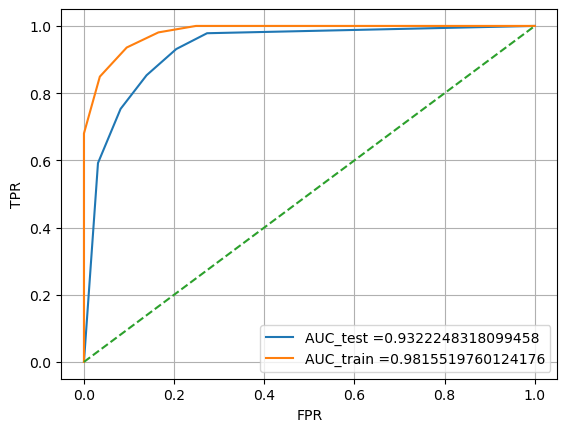

In [55]:
# visualise roc-auc curve
roc_auc(model_knn, X_train, y_train, X_test, y_test)

K-Nearest Neighbors - Train Set


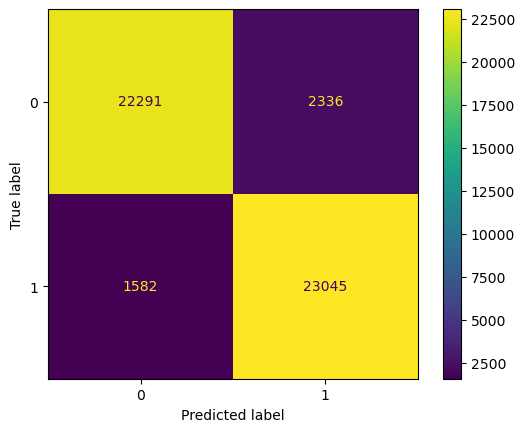

              precision    recall  f1-score   support

           0       0.93      0.91      0.92     24627
           1       0.91      0.94      0.92     24627

    accuracy                           0.92     49254
   macro avg       0.92      0.92      0.92     49254
weighted avg       0.92      0.92      0.92     49254



In [56]:
# visualise confusion matrix for knn set train
print('K-Nearest Neighbors - Train Set')
cm = confusion_matrix(y_train, y_pred_train_knn)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.show()
print(classification_report(y_train, y_pred_train_knn))

K-Nearest Neighbors - Test Set


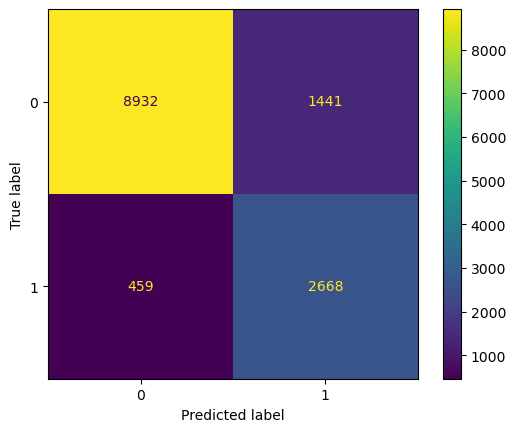

              precision    recall  f1-score   support

           0       0.95      0.86      0.90     10373
           1       0.65      0.85      0.74      3127

    accuracy                           0.86     13500
   macro avg       0.80      0.86      0.82     13500
weighted avg       0.88      0.86      0.87     13500



In [57]:
# visualise confusion matrix for knn set test
print('K-Nearest Neighbors - Test Set')
cm = confusion_matrix(y_test, y_pred_test_knn)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.show()
print(classification_report(y_test, y_pred_test_knn))

In [58]:
precision_knn = cross_val_score(model_knn,
                                X_train,
                                y_train,
                                cv = 2,
                                scoring = 'precision')

print('Precision Score - All - Cross Validation  : ', precision_knn)
print('Precision Score - Mean - Cross Validation : ', precision_knn.mean())
print('Precision Score - Std - Cross Validation  : ', precision_knn.std())
print('Precision Score - Range of Test-Set       : ', (precision_knn.mean() - precision_knn.std()) , '-', (precision_knn.mean() + precision_knn.std()))

Precision Score - All - Cross Validation  :  [0.86832    0.85926773]
Precision Score - Mean - Cross Validation :  0.8637938672768879
Precision Score - Std - Cross Validation  :  0.004526132723112142
Precision Score - Range of Test-Set       :  0.8592677345537758 - 0.86832


Explanation:

Based on AUC scores, the model is doing an excellent job to when separating between the approved customer' and not approved customers' on both set. ROC scores on train is 0.9815 and on test set is 0.9322. The higher the scores, the better the models when distiguished betweeen approved customers' and not approved customers'.

If we take a look at the confusion matrix for K-Nearest Neighbors, precision on the train set is 0.91 and on the test set is 0.65. Precision is used to determine how many customers' loans are predicted to be approved, but in reality, these types of customers' are not approveable. Precision scores on train set are excellent, but precision scores on test set are quite poor. Based on this performance, we can categorise this model as overfit, because the model is doing good on the set train, but is doing poorly on test set. The ability of the model to minimise predicted approved customers' loans that come out as not approved is not good.

The stability of the model is also important. We use weighted average precision and compare it to the precision score with cross cross-validation technique. The results show that there's a 0.02 difference outside the range of precision with cross-validation.

### B. Support Vector Evaluation

AUC-Score: Excellent


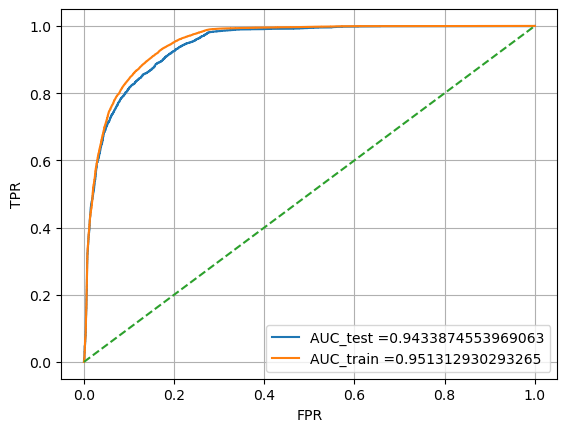

In [59]:
roc_auc(model_svc, X_train, y_train, X_test, y_test)

Support Vector Classifier - Train Set


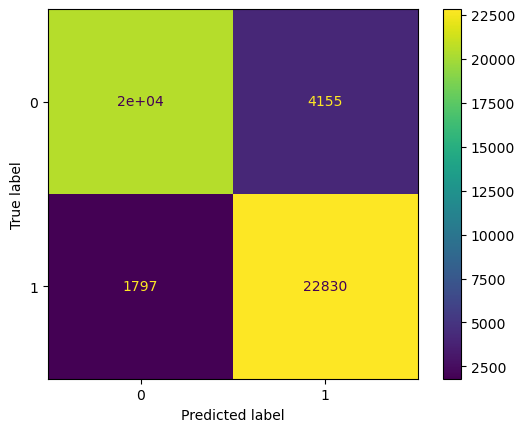

              precision    recall  f1-score   support

           0       0.92      0.83      0.87     24627
           1       0.85      0.93      0.88     24627

    accuracy                           0.88     49254
   macro avg       0.88      0.88      0.88     49254
weighted avg       0.88      0.88      0.88     49254



In [60]:
# visualise confusion matrix for svc set train
print('Support Vector Classifier - Train Set')
cm = confusion_matrix(y_train, y_pred_train_svc)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.show()
print(classification_report(y_train, y_pred_train_svc))

Support Vector Classifier - Test Set


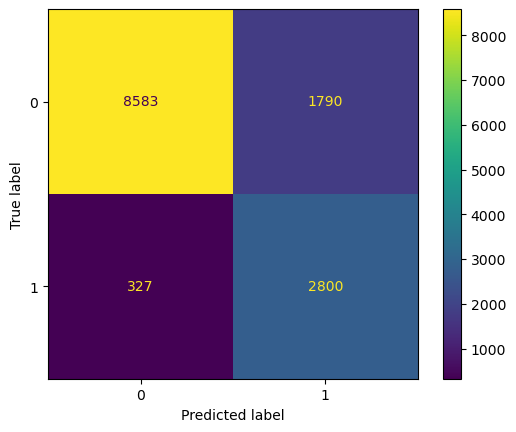

              precision    recall  f1-score   support

           0       0.96      0.83      0.89     10373
           1       0.61      0.90      0.73      3127

    accuracy                           0.84     13500
   macro avg       0.79      0.86      0.81     13500
weighted avg       0.88      0.84      0.85     13500



In [61]:
# visualise confusion matrix for svc set test
print('Support Vector Classifier - Test Set')
cm = confusion_matrix(y_test, y_pred_test_svc)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.show()
print(classification_report(y_test, y_pred_test_svc))

In [62]:
precision_svc = cross_val_score(model_svc,
                                X_train,
                                y_train,
                                cv = 2,
                                scoring = 'precision')

print('Precision Score - All - Cross Validation  : ', precision_svc)
print('Precision Score - Mean - Cross Validation : ', precision_svc.mean())
print('Precision Score - Std - Cross Validation  : ', precision_svc.std())
print('Precision Score - Range of Test-Set       : ', (precision_svc.mean() - precision_svc.std()) , '-', (precision_svc.mean() + precision_svc.std()))

Precision Score - All - Cross Validation  :  [0.84089716 0.8403554 ]
Precision Score - Mean - Cross Validation :  0.8406262798483286
Precision Score - Std - Cross Validation  :  0.00027087715414686464
Precision Score - Range of Test-Set       :  0.8403554026941817 - 0.8408971570024755


Explanation:

Based on the AUC scores, the model is doing an excellent job on both sets when distinguishing between approved customers' loan and not. ROC scores on the train set is 0.9513 and on the test set is 0.9433.

If we take a look on the confusion matrix for Support Vector Classifier, the model is doing an excellent job on the training set, but is doing poorly on the test set based on the precision score. Precision score on the train set is 0.85, and on the test set is 0.61. We can conclude that the model is categorised as overfit, because the model is doing great on the train set, but is doing poorly on the test set. The ability of the model to minimise predicted approved customers' loans that come out as not approved is not good.

The stability of the model is also important. We use weighted average precision and compare it to the precision score with cross cross-validation technique. The results show that there's a 0.04 difference outside the range of precision with cross-validation.

### C. Random Forest Evaluation

AUC-Score: Excellent


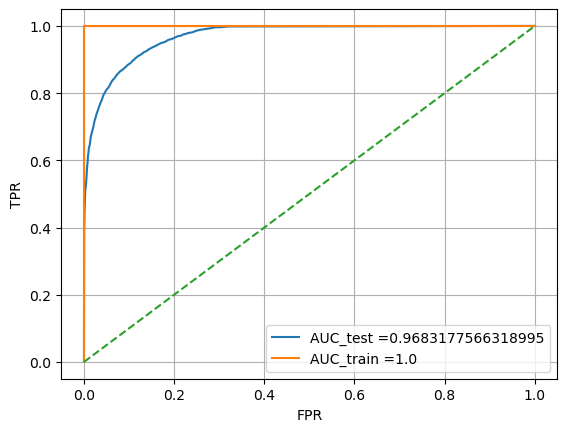

In [63]:
# visualise roc-auc curve for random forest model
roc_auc(model_rfc, X_train, y_train, X_test, y_test)

Random Forest Classifier - Train Set


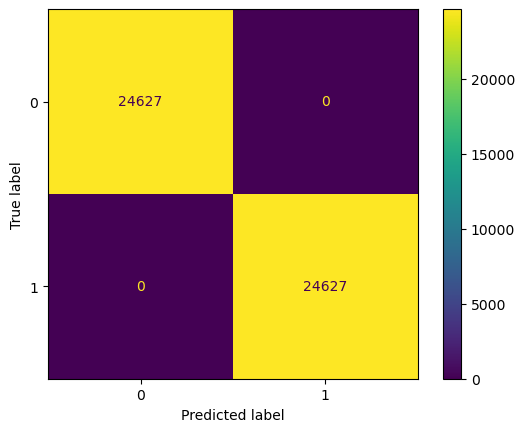

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     24627
           1       1.00      1.00      1.00     24627

    accuracy                           1.00     49254
   macro avg       1.00      1.00      1.00     49254
weighted avg       1.00      1.00      1.00     49254



In [64]:
# visualise confusion matrix for random forest set train
print('Random Forest Classifier - Train Set')
cm = confusion_matrix(y_train, y_pred_train_rfc)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.show()
print(classification_report(y_train, y_pred_train_rfc))

Random Forest Classifier - Test Set


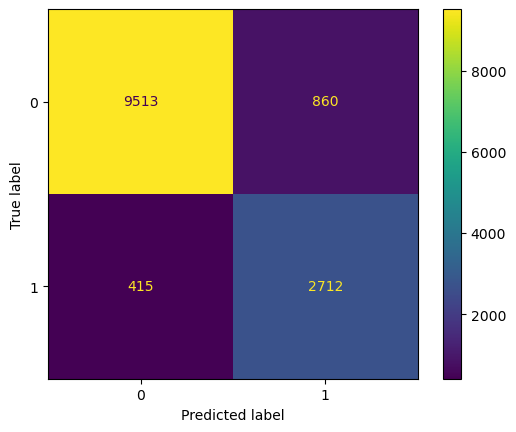

              precision    recall  f1-score   support

           0       0.96      0.92      0.94     10373
           1       0.76      0.87      0.81      3127

    accuracy                           0.91     13500
   macro avg       0.86      0.89      0.87     13500
weighted avg       0.91      0.91      0.91     13500



In [65]:
# visualise confusion matrix for randon forest set test
print('Random Forest Classifier - Test Set')
cm = confusion_matrix(y_test, y_pred_test_rfc)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.show()
print(classification_report(y_test, y_pred_test_rfc))

In [66]:
precision_rfc = cross_val_score(model_rfc,
                                X_train,
                                y_train,
                                cv = 2,
                                scoring = 'precision')

print('Precision Score - All - Cross Validation  : ', precision_rfc)
print('Precision Score - Mean - Cross Validation : ', precision_rfc.mean())
print('Precision Score - Std - Cross Validation  : ', precision_rfc.std())
print('Precision Score - Range of Test-Set       : ', (precision_rfc.mean() - precision_rfc.std()) , '-', (precision_rfc.mean() + precision_rfc.std()))

Precision Score - All - Cross Validation  :  [0.91707116 0.90480931]
Precision Score - Mean - Cross Validation :  0.9109402382144807
Precision Score - Std - Cross Validation  :  0.006130925915506957
Precision Score - Range of Test-Set       :  0.9048093122989738 - 0.9170711641299876


Explanation:

Based on AUC scores, the model is doing an excellent job on both sets when distinguishing between approved customers' loan and not. AUC scores on the train set is 1 and on the test set is 0.9681.

If we take a look at the confusion matrix for the Random forest model, the model is doing an excellent job on the train set and is doing quite good on the test set based on precision scores. Precision score on the train set is 1, and on the test set is 0.76. The difference between both sets of precision scores is quite large, so the model can be categorised as overfit. The ability of the model to minimise predicted approved customers' loans that come out as not approved is quite good, although we need to be careful, because the model is tends to memorize the data rather than learning the patterns.

The stability of the model is also important. We use weighted average precision and compare it to the precision score with cross cross-validation technique. The results show that the weighted average is int the range of precision with cross-validation

### D. Decision Tree Evaluation

AUC-Score: Very Good


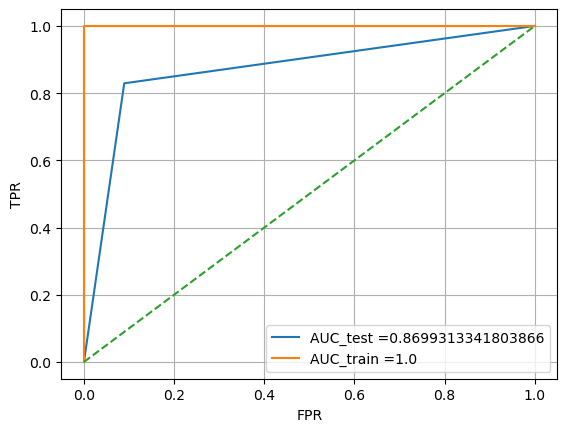

In [67]:
# visualise roc-auc curve for decision tree
roc_auc(model_dtc, X_train, y_train, X_test, y_test)

Decision Tree Classifier - Train Set


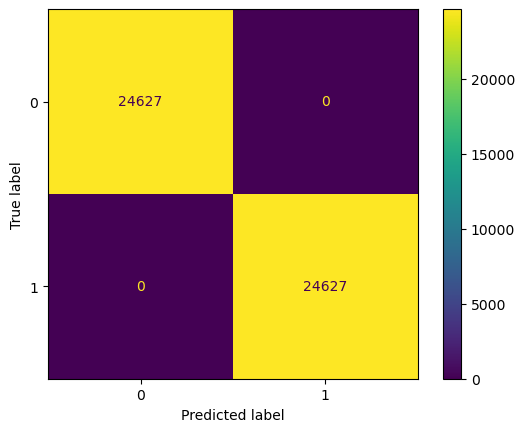

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     24627
           1       1.00      1.00      1.00     24627

    accuracy                           1.00     49254
   macro avg       1.00      1.00      1.00     49254
weighted avg       1.00      1.00      1.00     49254



In [68]:
# visualise confusion matrix for set train decision tree model
print('Decision Tree Classifier - Train Set')
cm = confusion_matrix(y_train, y_pred_train_dtc)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.show()
print(classification_report(y_train, y_pred_train_dtc))

Decision Tree Classifier - Test Set


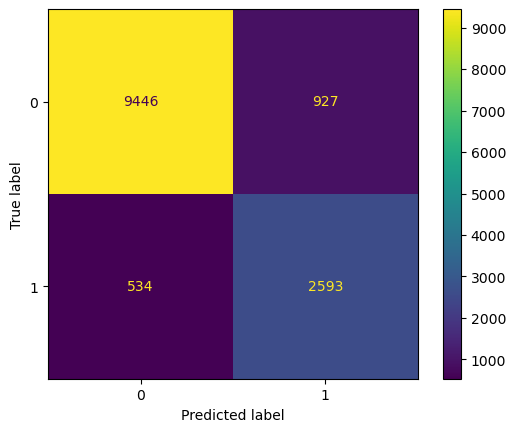

              precision    recall  f1-score   support

           0       0.95      0.91      0.93     10373
           1       0.74      0.83      0.78      3127

    accuracy                           0.89     13500
   macro avg       0.84      0.87      0.85     13500
weighted avg       0.90      0.89      0.89     13500



In [75]:
# visualise confusion matrix for set test decision tree model
print('Decision Tree Classifier - Test Set')
cm = confusion_matrix(y_test, y_pred_test_dtc)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.show()
print(classification_report(y_test, y_pred_test_dtc))

In [70]:
precision_dtc = cross_val_score(model_dtc,
                                X_train,
                                y_train,
                                cv = 2,
                                scoring = 'precision')

print('Precision Score - All - Cross Validation  : ', precision_dtc)
print('Precision Score - Mean - Cross Validation : ', precision_dtc.mean())
print('Precision Score - Std - Cross Validation  : ', precision_dtc.std())
print('Precision Score - Range of Test-Set       : ', (precision_dtc.mean() - precision_dtc.std()) , '-', (precision_dtc.mean() + precision_dtc.std()))

Precision Score - All - Cross Validation  :  [0.90684815 0.89823952]
Precision Score - Mean - Cross Validation :  0.9025438348680765
Precision Score - Std - Cross Validation  :  0.0043043148554453015
Precision Score - Range of Test-Set       :  0.8982395200126312 - 0.9068481497235219


Explanation:

Based on AUC scores on both sets, the result comes out excellent for the train set and good for the test set. AUC score for the train sets is 1, and for the test set is 0.8699. It is indicated that the models can distinguish between approved customers' loans and not.

If we look at precision scores for the Decision tree model, the model is performing great on the train set, and performing quite good on the test set. The difference between those scores is quite large, so it is categorised as overfit. The ability of the model to minimise predicted approved customers' loans that come out as not approved is quite good, although we need to be careful, because the model is tends to memorize the data rather than learning the patterns.

The stability of the model is also important. We use weighted average precision and compare it to the precision score with cross cross-validation technique. The results show that the weighted average is int the range of precision with cross-validation

### E. AdaBoost Evaluation

AUC-Score: Excellent


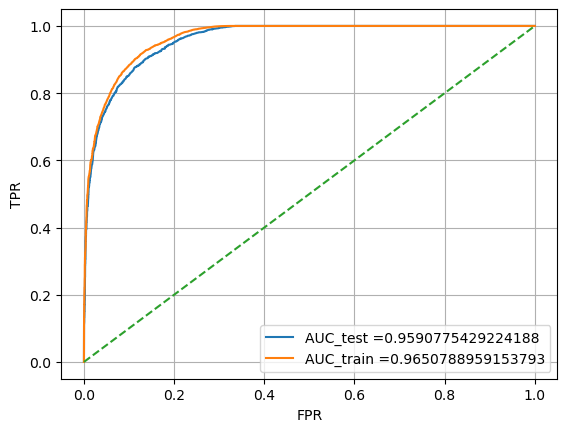

In [71]:
# visualise roc-auc curve
roc_auc(model_boost, X_train, y_train, X_test, y_test)

AdaBoost - Train Set


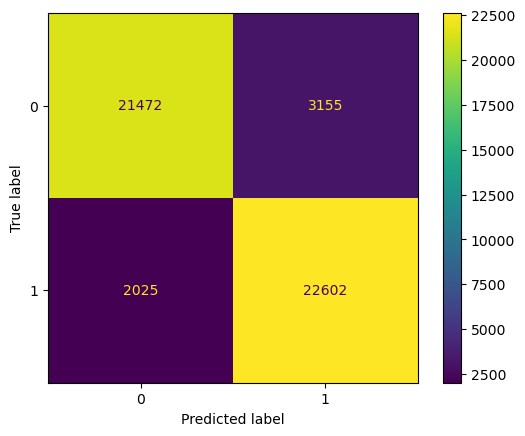

              precision    recall  f1-score   support

           0       0.91      0.87      0.89     24627
           1       0.88      0.92      0.90     24627

    accuracy                           0.89     49254
   macro avg       0.90      0.89      0.89     49254
weighted avg       0.90      0.89      0.89     49254



In [72]:
# visualise confusion matrix for set train AdaBoost model
print('AdaBoost - Train Set')
cm = confusion_matrix(y_train, y_pred_train_ada)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.show()
print(classification_report(y_train, y_pred_train_ada))

AdaBoost - Test Set


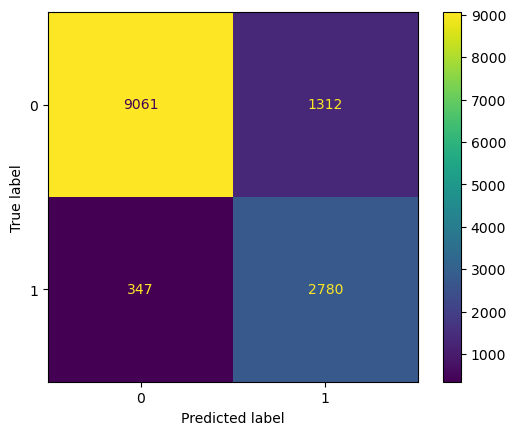

              precision    recall  f1-score   support

           0       0.96      0.87      0.92     10373
           1       0.68      0.89      0.77      3127

    accuracy                           0.88     13500
   macro avg       0.82      0.88      0.84     13500
weighted avg       0.90      0.88      0.88     13500



In [73]:
# visualise confusion matrix for set train AdaBoost model
print('AdaBoost - Test Set')
cm = confusion_matrix(y_test, y_pred_test_ada)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.show()
print(classification_report(y_test, y_pred_test_ada))

In [74]:
precision_ada = cross_val_score(model_boost,
                                X_train,
                                y_train,
                                cv = 2,
                                scoring = 'precision')

print('Precision Score - All - Cross Validation  : ', precision_ada)
print('Precision Score - Mean - Cross Validation : ', precision_ada.mean())
print('Precision Score - Std - Cross Validation  : ', precision_ada.std())
print('Precision Score - Range of Test-Set       : ', (precision_ada.mean() - precision_ada.std()) , '-', (precision_ada.mean() + precision_ada.std()))

Precision Score - All - Cross Validation  :  [0.87472319 0.86901973]
Precision Score - Mean - Cross Validation :  0.8718714576322022
Precision Score - Std - Cross Validation  :  0.002851731232081267
Precision Score - Range of Test-Set       :  0.8690197264001209 - 0.8747231888642835


Explanation:

Based on the AUC score on both sets, the model performs great when distinguishing between approved customers' loans and not. AUC scores on the train set is 0.88 and on the test set is 0.68.

If we look at the confusion matrix for the AdaBoost model, the model is performing great on the train set, but is performing poorly on the test set. We can conclude that the model is categorised as overfit, because the model performs poorly on the train set, but performs poorly on the test set with a precision score of only 0.68. The ability of the model to minimise predicted approved customers' loans that come out as not approved is not good.

The stability of the model is also important. We use weighted average precision and compare it to the precision score with cross cross-validation technique. The results show that there's a 0.03 difference outside the range of precision with cross-validation.

### F. Final Decision for Hyperparameter Tuning

From all of the models that we compare, here's the advantage and disadvantage from the models we are used:

- Advantage of K-Nearest Neighbors model:
    - Simple to use when we are uses the model
    - There's no training step
    - Few parameter to set, because this models having only 2 parameter, number of neighbors and distance.
- Disadvantage of K-Nearest Neighbors model:
    - Slow when handling larger data
    - Struggles with many features, so selection process for this model is important.
    - High tendency to overfit

- Advantage of Support Vector Machine model:
    - Performs well on high dimensional data.
    - Higher capability for non-linear data.
    - SVM have parameter to ignore outliers.
    - Efficient when using memory.
- Disadvantage of Support Vector Machine model:
    - Slower when using larger data(one of the most slowest machine learning algorithm).
    - Sensitivity to noise and overrlapping between classes that can limiting effectiveness in real-world scenarios

- Advantage of Random Forest model:
    - Providing high accuracy prediction with large datasets.
    - Doesn't require normalization or stardarization on dataset.
- Disadvantage of Random Forest model:
    - Expensive in computation if we use a larger number of trees.

- Advantage of Decision Tree model:
    - Can handle non-linear data.
    - Simple interpretability.
    - No need for feature scalling.
- Disadvantage of Decision Tree model:
    - Strong tendency to overfitting.
    - Higher bias towards categories with many levels.

- Advantage of AdaBoost Model:
    - High precision when doing prediction.
    - Less prone to overfitting.
- Disadvantange of Adaboost Model:
    - Sensitive to outliers.
    - Large resource is needed for this model.

[Model evaluation shows that Decision Tree and Random Forest are the best models to use among all five models. The ability to minimise predicted customers' loan approvals that are not approvable is important. Weighted average precision shows that both Decision Tree and Random Forest are in the range of precision score with cross validation.](https://docs.kolena.com/metrics/averaging-methods/#:~:text=If%20you%20want%20to%20treat,average%20instead%20of%20macro%20average.) [We will use Random Forest in the hyperparameter tuning process to get the best result from it. Random Forest also has an advantage because of its high accuracy with large datasets and can prevent overfitting.](https://carpentries-incubator.github.io/ml4bio-workshop/04-trees-overfitting/index.html#:~:text=Random%20forests%20deals%20with%20the,to%20make%20the%20final%20classification.)

## X. Hyperparameter Tuning

### A. Model Training

#### 1. Finding Best Parameter

In [141]:
# hyperparameter for tuning
random_search_params = {'rfc__min_samples_split': [5, 10, 15, 20,  25],
                        'rfc__min_samples_leaf': [10, 20, 30, 40, 50],
                        'rfc__max_depth' : [5, 10, 15, 20, 25],
                        'rfc__max_leaf_nodes' : [20, 30, 30, 40, 50]}
random_search_params

{'rfc__min_samples_split': [5, 10, 15, 20, 25],
 'rfc__min_samples_leaf': [10, 20, 30, 40, 50],
 'rfc__max_depth': [5, 10, 15, 20, 25],
 'rfc__max_leaf_nodes': [20, 30, 30, 40, 50]}

In [142]:
# tuning process with determine hyperparameter
rfc_randomcv = RandomizedSearchCV(estimator = model_rfc,
                                  param_distributions = random_search_params,
                                  n_iter = 50,
                                  cv = 5,
                                  scoring = 'precision',
                                  n_jobs = 1,
                                  random_state = 45)

In [143]:
# hyperparameter tuning process
rfc_randomcv.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('prepospipe',
                                              ColumnTransformer(transformers=[('pipe_num',
                                                                               Pipeline(steps=[('scaler_minmax',
                                                                                                MinMaxScaler())]),
                                                                               ['person_income',
                                                                                'loan_int_rate',
                                                                                'loan_percent_income']),
                                                                              ('pipe_cat',
                                                                               Pipeline(steps=[('encode_onehot',
                                                                                                OneHotEncoder())]),
                                                                               ['person_home_ownership',
                                                                                'prev_loan_defaults'])])),
                                             ('rfc',
                                              RandomForestClassifier(random_state=45))]),
                   n_iter=50, n_jobs=1,
                   param_distributions={'rfc__max_depth': [5, 10, 15, 20, 25],
                                        'rfc__max_leaf_nodes': [20, 30, 30, 40,
                                                                50],
                                        'rfc__min_samples_leaf': [10, 20, 30,
                                                                  40, 50],
                                        'rfc__min_samples_split': [5, 10, 15,
                                                                   20, 25]},
                   random_state=45, scoring='precision')

In [144]:
# display best parameter for training prceoss
rfc_randomcv.best_params_

{'rfc__min_samples_split': 15,
 'rfc__min_samples_leaf': 20,
 'rfc__max_leaf_nodes': 50,
 'rfc__max_depth': 20}

#### 2. Create Pipeline

In [145]:
# declaration model with best parameter
rfc_inf = RandomForestClassifier(min_samples_split = 15, 
                                 min_samples_leaf = 20, 
                                 max_leaf_nodes = 50,
                                 max_depth = 20)

# pipeline for final model and inference
model_inf = Pipeline([('prepospipe', preprocessing_pipeline),
                      ('inf', rfc_inf)])

#### 3. Model Training

In [146]:
# model learning process
model_inf.fit(X_train, y_train)

Pipeline(steps=[('prepospipe',
                 ColumnTransformer(transformers=[('pipe_num',
                                                  Pipeline(steps=[('scaler_minmax',
                                                                   MinMaxScaler())]),
                                                  ['person_income',
                                                   'loan_int_rate',
                                                   'loan_percent_income']),
                                                 ('pipe_cat',
                                                  Pipeline(steps=[('encode_onehot',
                                                                   OneHotEncoder())]),
                                                  ['person_home_ownership',
                                                   'prev_loan_defaults'])])),
                ('inf',
                 RandomForestClassifier(max_depth=20, max_leaf_nodes=50,
                                        min_samples_leaf=20,
                                        min_samples_split=15))])

In [147]:
# predict with trained model
y_pred_train_inf = model_inf.predict(X_train)
y_pred_test_inf = model_inf.predict(X_test)

### B. Model Evaluation

AUC-Score: Excellent


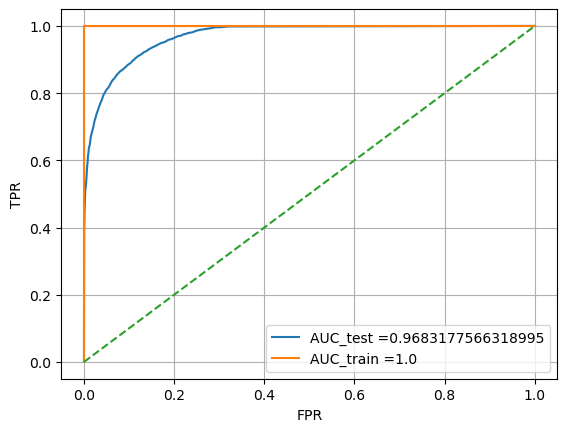

In [153]:
# visualise roc-auc curve before tuning
roc_auc(model_rfc, X_train, y_train, X_test, y_test)

AUC-Score: Excellent


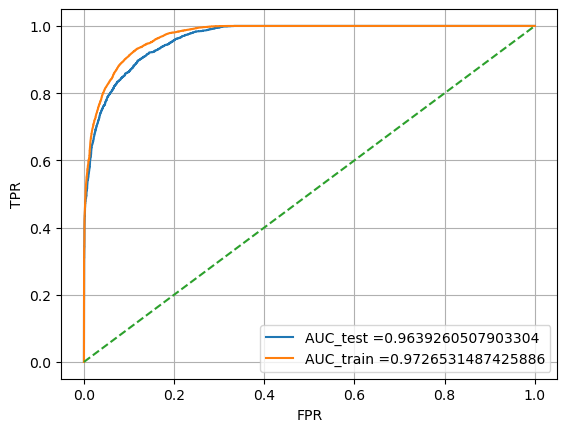

In [ ]:
# visualise roc-auc curve after tuning
roc_auc(model_inf, X_train, y_train, X_test, y_test)

Random Forest Classifier - Train Set (Before Tuning)


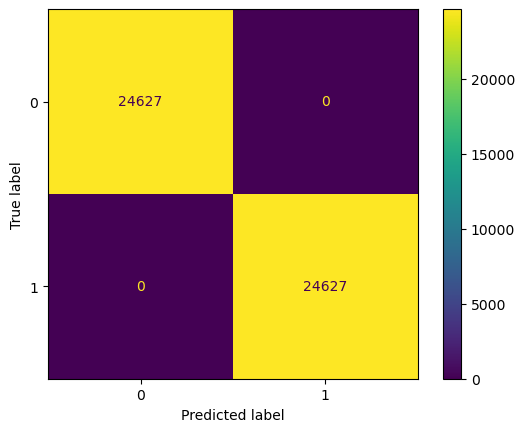

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     24627
           1       1.00      1.00      1.00     24627

    accuracy                           1.00     49254
   macro avg       1.00      1.00      1.00     49254
weighted avg       1.00      1.00      1.00     49254



In [149]:
# visualise confusion matrix for random forest set train
print('Random Forest Classifier - Train Set (Before Tuning)')
cm = confusion_matrix(y_train, y_pred_train_rfc)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.show()
print(classification_report(y_train, y_pred_train_rfc))

Random Forect Classifier Train set(After Tuning)


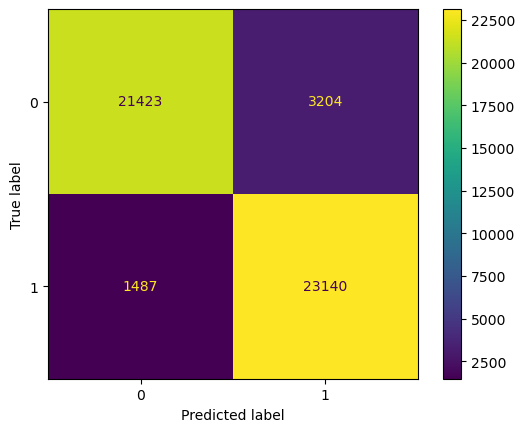

              precision    recall  f1-score   support

           0       0.94      0.87      0.90     24627
           1       0.88      0.94      0.91     24627

    accuracy                           0.90     49254
   macro avg       0.91      0.90      0.90     49254
weighted avg       0.91      0.90      0.90     49254



In [150]:
# visualise confusion matrix on train set before tuning
print('Random Forect Classifier Train set(After Tuning)')
cm = confusion_matrix(y_train, y_pred_train_inf)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.show()
print(classification_report(y_train, y_pred_train_inf))

Random Forest Classifier - Test Set (Before Tuning)


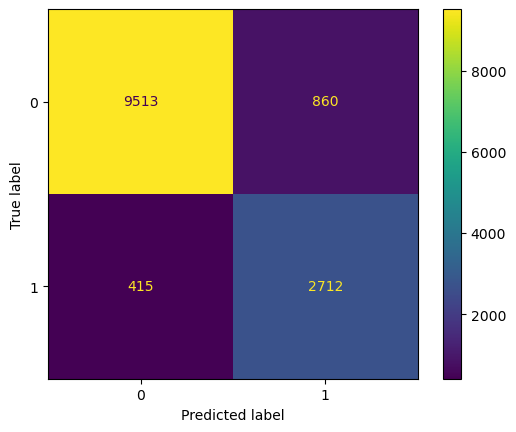

              precision    recall  f1-score   support

           0       0.96      0.92      0.94     10373
           1       0.76      0.87      0.81      3127

    accuracy                           0.91     13500
   macro avg       0.86      0.89      0.87     13500
weighted avg       0.91      0.91      0.91     13500



In [151]:
# visualise confusion matrix for randon forest set test
# before tuning
print('Random Forest Classifier - Test Set (Before Tuning)')
cm = confusion_matrix(y_test, y_pred_test_rfc)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.show()
print(classification_report(y_test, y_pred_test_rfc))

Random Forect Classifier Test set(After Tuning)


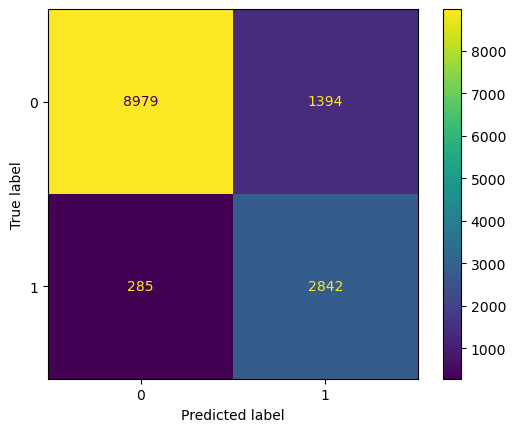

              precision    recall  f1-score   support

           0       0.97      0.87      0.91     10373
           1       0.67      0.91      0.77      3127

    accuracy                           0.88     13500
   macro avg       0.82      0.89      0.84     13500
weighted avg       0.90      0.88      0.88     13500



In [152]:
# visualise confusion matrix on train set before tuning
print('Random Forect Classifier Test set(After Tuning)')
cm = confusion_matrix(y_test, y_pred_test_inf)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.show()
print(classification_report(y_test, y_pred_test_inf))

In [157]:
# cross validation score before tuning
precision_rfc = cross_val_score(model_rfc,
                                X_train,
                                y_train,
                                cv = 2,
                                scoring = 'precision')

print('Precision Score - All - Cross Validation (Before Tuning)  : ', precision_rfc)
print('Precision Score - Mean - Cross Validation (Before Tuning) : ', precision_rfc.mean())
print('Precision Score - Std - Cross Validation (Before Tuning) : ', precision_rfc.std())
print('Precision Score - Range of Test-Set (Before Tuning): ', (precision_rfc.mean() - precision_rfc.std()) , '-', (precision_rfc.mean() + precision_rfc.std()))

Precision Score - All - Cross Validation (Before Tuning)  :  [0.91707116 0.90480931]
Precision Score - Mean - Cross Validation (Before Tuning) :  0.9109402382144807
Precision Score - Std - Cross Validation (Before Tuning) :  0.006130925915506957
Precision Score - Range of Test-Set (Before Tuning):  0.9048093122989738 - 0.9170711641299876


In [158]:
# cross validation after tuning
precision_inf = cross_val_score(model_inf,
                                X_train,
                                y_train,
                                cv = 2,
                                scoring = 'precision')

print('Precision Score - All - Cross Validation (After Tuning) : ', precision_inf)
print('Precision Score - Mean - Cross Validation (After Tuning) : ', precision_inf.mean())
print('Precision Score - Std - Cross Validation (After Tuning) : ', precision_inf.std())
print('Precision Score - Range of Test-Set (After Tuning) : ', (precision_inf.mean() - precision_inf.std()) , '-', (precision_inf.mean() + precision_inf.std()))

Precision Score - All - Cross Validation (After Tuning) :  [0.87065711 0.87605549]
Precision Score - Mean - Cross Validation (After Tuning) :  0.8733563013921526
Precision Score - Std - Cross Validation (After Tuning) :  0.00269918714825762
Precision Score - Range of Test-Set (After Tuning) :  0.870657114243895 - 0.8760554885404102


Explanation:

ROC-AUC curve shows that the model can distinguish between approved customers' loan and not. Both sets of AUC score when before tuning and after tuning are excellent. If we look on the precision score on train set, precision score before tuning is higher than after tuning, with a value difference of 0.12. We can say that, result before tuning and after tuning is excellent. Meanwhile, on test set, precision score after we tuning the hyperparameter is decreased from 0.76 to 0.67. It is indicated that the model after we tuning the hyperparameter are categorised as overfit.

We need to check the result consistency of the model. A method for checking the consistency of the model is uses cross-validation score. We can see that the model before and after we do tuning process has quite consistent results, based on comparison between the weighted average precision score and the range of precision score on the test set from cross validation score.

We can conclude that model before hyperparameter tuning is uses for model inference, because it is have better result than after hyperparameter tuning.

## XI. Model Saving

In [ ]:
# saving model process
with open('model.pkl', 'wb') as file:
    pickle.dump(model_rfc, file)

## XII. Model Inference

Model inference process is on another notebook. Input user for the inference process is consists of:

- Age: 28.0
- Gender: male
- Education: Bachelor:
- Annual income: 50000.0
- Employment experience: 5
- Home ownership: RENT
- Requested loan amount: 8500
- Loan intetion: PERSONAL
- Interest rate: 8.00
- Percentage of loan from annual income: 0.16
- History of credit length: 6.00
- Credit score: 500
- Previous loan defaults: No

From the resuts prediction, this customers' loan request are not approved.

## XIII. Conclusion and Recommendation

Conclusion:

Random Forest Classifier model before hyperparameter tuning process is prefereable for doing prediction on customers' loan request approval. [We can get a prediction around 76% of our predicted approved customers' loan are actually approveable customers'. That percentange comes from precision score when using that model at 0.76, which's a good result.](https://wiki.cloudfactory.com/docs/mp-wiki/metrics/precision?)

Recommendation:

Our model is performing good in model inference process, but because the model is overfit, maybe the result is just come out by chance. To improve our prediction, using Grid Search method on hyperparameter tuning is preferable rather than using Random Search method. Grid Search can provide better parameter for a better result. Higher percentange of predicted customers' loan approval that actually is an approveable customers' can be achieved.